c:\Users\attar\Desktop\Mahiboob_Attar_DataSceince\datascience\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


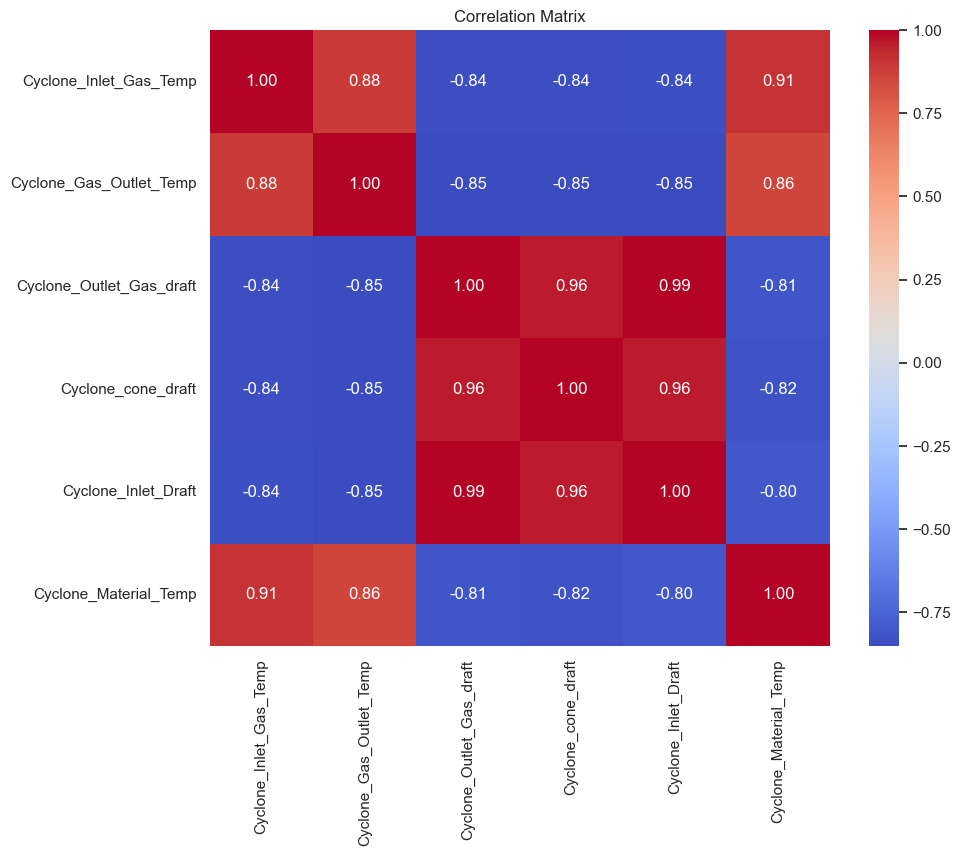

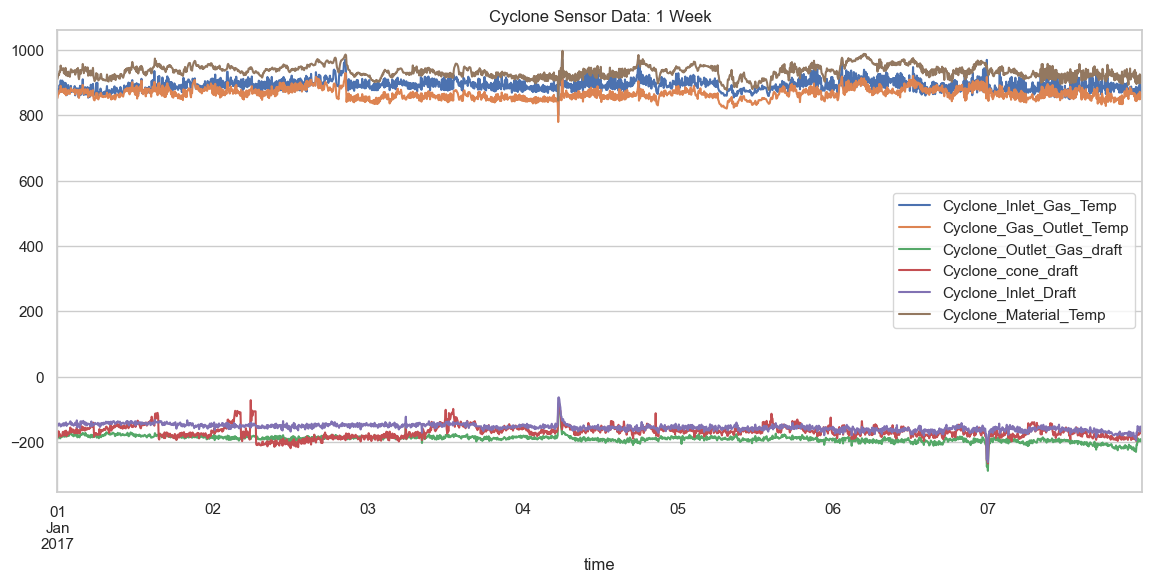

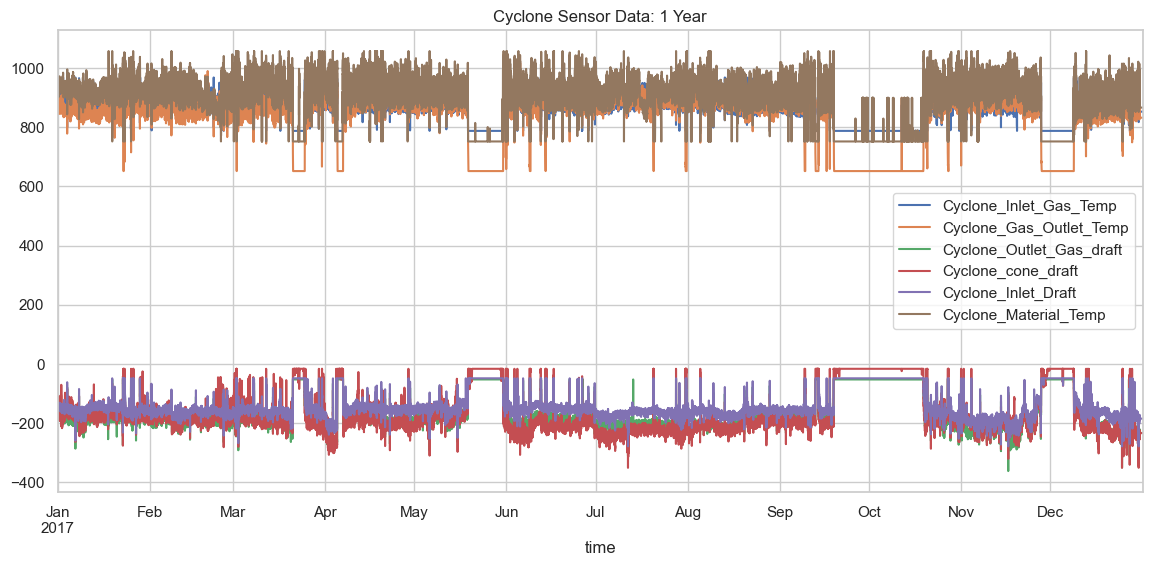

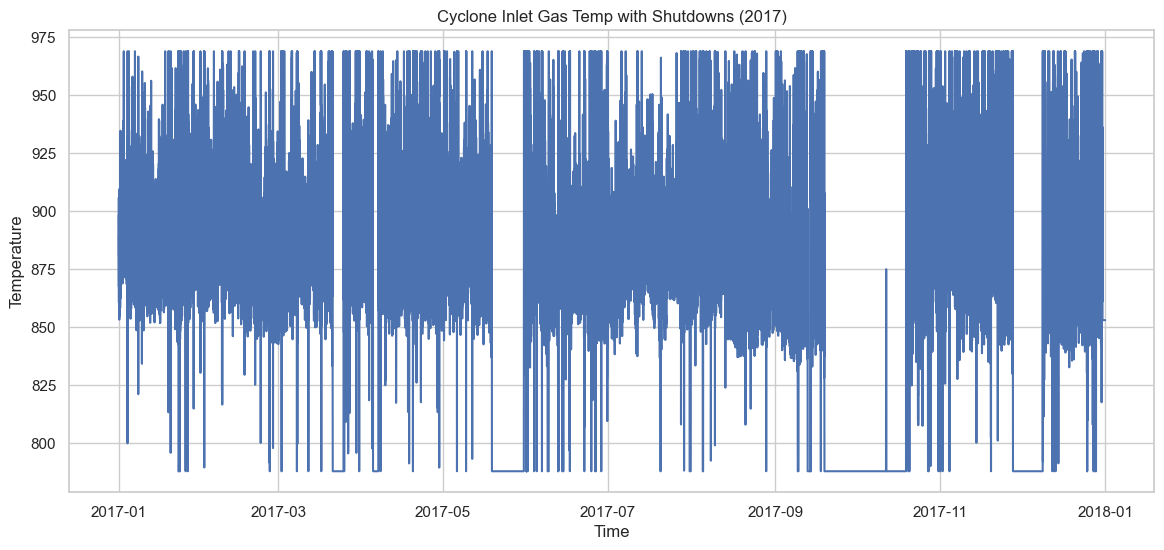

C:\Users\attar\AppData\Local\Temp\ipykernel_37820\1002314423.py:176: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pred_persist.fillna(method='bfill', inplace=True)


Persistence RMSE: 16.10 MAE: 9.82
ARIMA RMSE: 55.66 MAE: 38.08


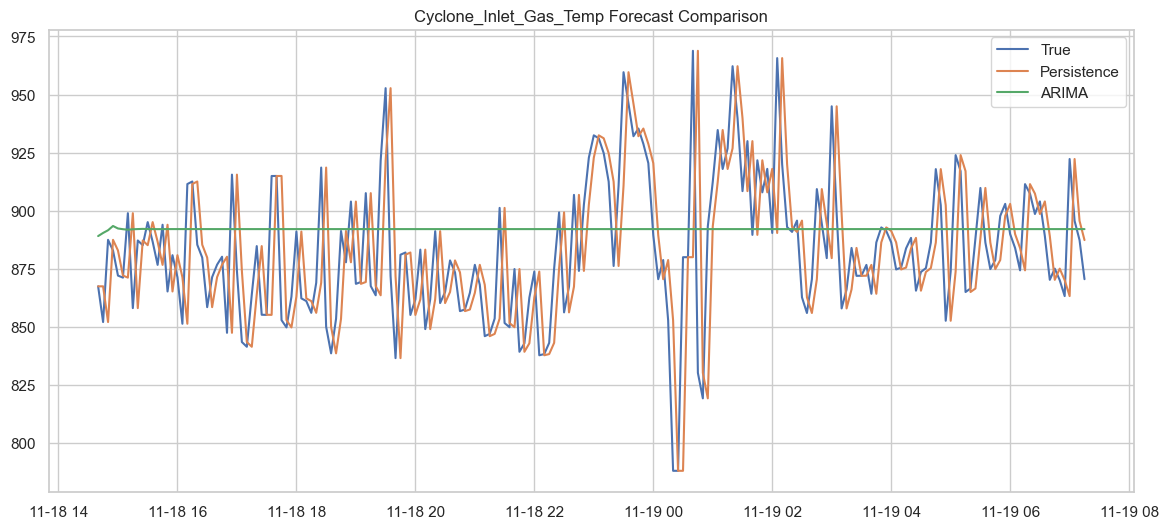

All outputs saved in Task1/outputs/ and plots in Task1/plots/


In [20]:
# ===========================
# Task 1: Machine Data Analysis
# ===========================

# Step 0: Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

# ===========================
# Step 1: Setup folders
# ===========================
os.makedirs("Task1/plots", exist_ok=True)
os.makedirs("Task1/outputs", exist_ok=True)

# ===========================
# Step 2: Load Dataset
# ===========================
file_path = "cyclone_data.xlsx"
df = pd.read_excel(file_path)

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Sensor columns
sensor_cols = [
    'Cyclone_Inlet_Gas_Temp', 'Cyclone_Gas_Outlet_Temp', 
    'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 
    'Cyclone_Inlet_Draft', 'Cyclone_Material_Temp'
]

# Convert to numeric
for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert timestamp
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df.set_index('time', inplace=True)

df_numeric = df[sensor_cols]

# ===========================
# Step 3: Resample & Fill Missing
# ===========================
df_numeric = df_numeric.resample('5min').mean()
df_numeric.ffill(inplace=True)
df_numeric.bfill(inplace=True)

# ===========================
# Step 4: Remove Outliers (IQR)
# ===========================
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    data[col] = np.clip(data[col], lower, upper)

for col in df_numeric.columns:
    remove_outliers_iqr(df_numeric, col)

# ===========================
# Step 5: Exploratory Analysis
# ===========================
df_numeric.describe().to_csv("Task1/outputs/summary_statistics.csv")

plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("Task1/plots/correlation_matrix.png")
plt.show()

# Weekly & Yearly plots
df_numeric['2017-01-01':'2017-01-07'].plot(title="Cyclone Sensor Data: 1 Week")
plt.savefig("Task1/plots/one_week.png")
plt.show()

df_numeric['2017-01-01':'2017-12-31'].plot(title="Cyclone Sensor Data: 1 Year")
plt.savefig("Task1/plots/one_year.png")
plt.show()

# ===========================
# Step 6: Dynamic Shutdown Detection
# ===========================
# Compute low threshold per sensor (5th percentile)
thresholds = df_numeric.quantile(0.05)

# Shutdown if >80% sensors below threshold
shutdown_mask = (df_numeric < thresholds).mean(axis=1) > 0.8

# Detect shutdown periods
shutdowns = []
in_shutdown = False
for time, is_down in shutdown_mask.items():
    if is_down and not in_shutdown:
        start_time = time
        in_shutdown = True
    elif not is_down and in_shutdown:
        end_time = time
        shutdowns.append({
            'start': start_time,
            'end': end_time,
            'duration_min': (end_time-start_time).total_seconds()/60
        })
        in_shutdown = False
# Handle if last period continues
if in_shutdown:
    end_time = shutdown_mask.index[-1]
    shutdowns.append({
        'start': start_time,
        'end': end_time,
        'duration_min': (end_time-start_time).total_seconds()/60
    })

shutdown_df = pd.DataFrame(shutdowns)
shutdown_df.to_csv("Task1/outputs/shutdown_periods.csv", index=False)

# Plot shutdowns
plt.figure(figsize=(14,6))
plt.plot(df_numeric['2017-01-01':'2017-12-31']['Cyclone_Inlet_Gas_Temp'], label='Cyclone_Inlet_Gas_Temp')
for _, row in shutdown_df.iterrows():
    plt.axvspan(row['start'], row['end'], color='red', alpha=0.3)
plt.title("Cyclone Inlet Gas Temp with Shutdowns (2017)")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.savefig("Task1/plots/shutdowns_year.png")
plt.show()

# ===========================
# Step 7: Machine State Clustering
# ===========================
active_data = df_numeric[~shutdown_mask].copy()
kmeans = KMeans(n_clusters=4, random_state=42)
active_data['cluster'] = kmeans.fit_predict(active_data)

cluster_summary = active_data.groupby('cluster').agg(['mean','std','count'])
cluster_summary.to_csv("Task1/outputs/clusters_summary.csv")

# ===========================
# Step 8: Contextual Anomaly Detection
# ===========================
anomalies_list = []
for cluster_id in active_data['cluster'].unique():
    cluster_data = active_data[active_data['cluster']==cluster_id].copy()
    iso = IsolationForest(contamination=0.01, random_state=42)
    cluster_data['anomaly'] = iso.fit_predict(cluster_data[sensor_cols])
    cluster_anomalies = cluster_data[cluster_data['anomaly']==-1]
    for idx, row in cluster_anomalies.iterrows():
        anomalies_list.append({
            'time': idx,
            'cluster': cluster_id,
            **row[sensor_cols].to_dict()
        })
anomalies_df = pd.DataFrame(anomalies_list)
anomalies_df.to_csv("Task1/outputs/anomalous_periods.csv", index=False)

# ===========================
# Step 9: Short-Horizon Forecasting
# ===========================
y = df_numeric['Cyclone_Inlet_Gas_Temp']
train_size = int(0.8*len(y))
train, test = y[:train_size], y[train_size:]

# Persistence
pred_persist = test.shift(1)
pred_persist.fillna(method='bfill', inplace=True)
rmse_persist = np.sqrt(mean_squared_error(test, pred_persist))
mae_persist = mean_absolute_error(test, pred_persist)

# ARIMA
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()
pred_arima = model_fit.forecast(len(test))
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
mae_arima = mean_absolute_error(test, pred_arima)

print(f"Persistence RMSE: {rmse_persist:.2f} MAE: {mae_persist:.2f}")
print(f"ARIMA RMSE: {rmse_arima:.2f} MAE: {mae_arima:.2f}")

# Save forecasts
forecasts_df = pd.DataFrame({
    'true': test,
    'persist_pred': pred_persist,
    'arima_pred': pred_arima
})
forecasts_df.to_csv("Task1/outputs/forecasts.csv")

plt.figure(figsize=(14,6))
plt.plot(test.index[:200], test.values[:200], label='True')
plt.plot(test.index[:200], pred_persist[:200], label='Persistence')
plt.plot(test.index[:200], pred_arima[:200], label='ARIMA')
plt.title("Cyclone_Inlet_Gas_Temp Forecast Comparison")
plt.legend()
plt.savefig("Task1/plots/forecast_comparison.png")
plt.show()

print("All outputs saved in Task1/outputs/ and plots in Task1/plots/")
